# Imports

In [1]:
# Add the directory where starships' directory is located
from sys import path
path.append('/home/mathisb/Github/starships')

# Add the directory containing the input data (opacity, abundance and stellar specs files)
import os
os.environ['pRT_input_data_path'] = '/home/mathisb/projects/def-ncowan/input_data'


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import starships.homemade as hm
from starships import spectrum as spectrum
from starships.mask_tools import interp1d_masked

interp1d_masked.iprint=False
import warnings

import astropy.constants as const
import astropy.units as u
import numpy as np
import starships.planet_obs as pl_obs
import starships.plotting_fcts as pf
from starships.planet_obs import Observations

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

In [3]:
%matplotlib inline

# Get planet info and determine directories to use

In [24]:
#--------------------------------------------------------------------------------------------
# Planet, night, reduction and instrument
pl_name = 'WASP-33 b'
visit_name = '2019-10-07'
reduction = 'v001'
instrument = "SPIRou"

#--------------------------------------------------------------------------------------------

# Directory where to save reductions
# > use scratch if available, use home if not
try:
    out_dir = Path(os.environ['SCRATCH'])
except KeyError:
    out_dir = Path.home()


# Output reductions in dedicated directory
pl_name_fname = ''.join(pl_name.split())
out_dir /= Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit_name}/{reduction}')
# Make sure the  directory exists
out_dir.mkdir(parents=True, exist_ok=True)


In [25]:
# Relevant directories

# Where to find the observations (data)?
obs_dir = "/home/mathisb/projects/def-ncowan/SPIRou_Observations/WASP-33b/v07232/WASP-33b/"

# Where to save figures?
path_fig = Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit_name}/Figures')

In [26]:
# All the observations must be listed in files.
# We need the e2ds and the telluric corrected spectra.

list_filenames = {'list_e2ds': f'list_e2ds_visit_{visit_name}',
                  'list_tcorr': f'list_tcorr_visit_{visit_name}',
                  'list_recon': f'list_recon_visit_{visit_name}'}

In [27]:
# SPECIFY PARAMETERS OF THE PLANET
# If not specified, the default parameters from exofile are taken.

ap = 0.0259*u.au
R_star = (ap/3.69).to(u.R_sun)
R_pl = (0.1143*R_star).to(u.R_jup)
M_star = 1.561*const.M_sun

# #-----------------------------------------------------------#


obs = Observations(name=pl_name, 
                   pl_kwargs = {
                                'M_star': M_star, 
                                'R_star': R_star,
                                'ap': ap,
                                'R_pl': R_pl,
                                # 'mid_tr': mid_tr,
                                # 'excent': e,
                                # 'w': w
                                }
                  )

# Get the data
obs.fetch_data(obs_dir, **list_filenames, CADC=False)
p = obs.planet

# # Verify that the info is good
# print("\n" + "M_star:", M_star, "\t", "R_star:", R_star, "\nap:", ap, "\t", "R_pl:", R_pl,  "\t", 
#       "mid_tr:", mid_tr, "\ne:", e,  "\t", "w:", w)

INFO:starships.planet_obs:Getting WASP-33 b from ExoFile
INFO:starships.planet_obs:Changing M_star from [3.28087629e+30] kg to 3.1039078081596574e+30 kg
INFO:starships.planet_obs:It became [3.10390781e+30] kg
INFO:starships.planet_obs:Changing R_star from [1.11312e+09] m to 1.5093042904789116 solRad
INFO:starships.planet_obs:It became [1.05002299e+09] m
INFO:starships.planet_obs:Changing ap from [3.8222256e+09] m to 0.0259 AU
INFO:starships.planet_obs:It became [3.87458485e+09] m
INFO:starships.planet_obs:Changing R_pl from [1.07023524e+08] m to 1.6787560610346646 jupiterRad
INFO:starships.planet_obs:It became [1.20017628e+08] m
INFO:starships.planet_obs:Fetching the uncorrected spectra
INFO:starships.planet_obs:File: list_e2ds_visit_2019-10-07
INFO:starships.planet_obs:Fetching data
INFO:starships.planet_obs:File: list_tcorr_visit_2019-10-07
INFO:starships.planet_obs:Fetching the tellurics
INFO:starships.planet_obs:File: list_recon_visit_2019-10-07


# Look at the reductions

[2454163.22367] d
Emission


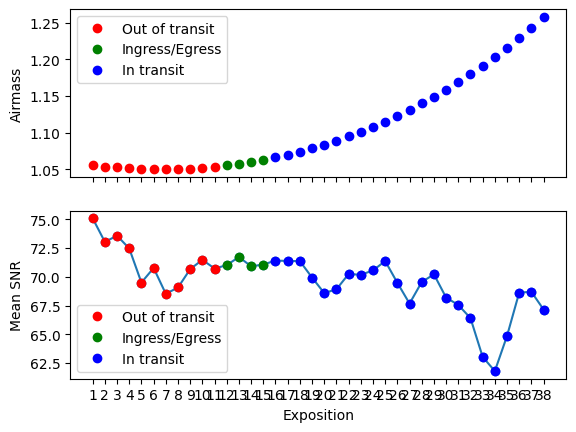

In [28]:
# Name of reduction sequence files
seq_file_list = [
                f"sequence_0-pc_mask_wings97_data_trs_{visit_name}.npz",
                # f"sequence_1-pc_mask_wings97_data_trs_{visit_name}.npz",
                # f"sequence_2-pc_mask_wings97_data_trs_{visit_name}.npz",
                # f"sequence_3-pc_mask_wings97_data_trs_{visit_name}.npz",
                # f"sequence_4-pc_mask_wings97_data_trs_{visit_name}.npz",
                # f"sequence_5-pc_mask_wings97_data_trs_{visit_name}.npz",
                # f"sequence_6-pc_mask_wings97_data_trs_{visit_name}.npz",
                # f"sequence_7-pc_mask_wings97_data_trs_{visit_name}.npz",
                # f"sequence_8-pc_mask_wings97_data_trs_{visit_name}.npz",
                # f"sequence_9-pc_mask_wings97_data_trs_{visit_name}.npz",
                # f"sequence_10-pc_mask_wings97_data_trs_{visit_name}.npz",
                ]

#----------------------------#

# Plot airmass and mean SNR
seq_obj_list = []

for seq_file in seq_file_list:
    sequence_obj = pl_obs.load_single_sequences(seq_file, name=pl_name, planet=p, path=out_dir, load_all=True)
    seq_obj_list.append(sequence_obj)

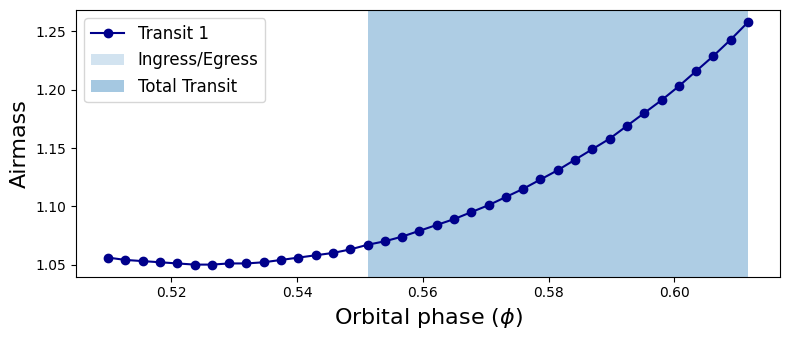

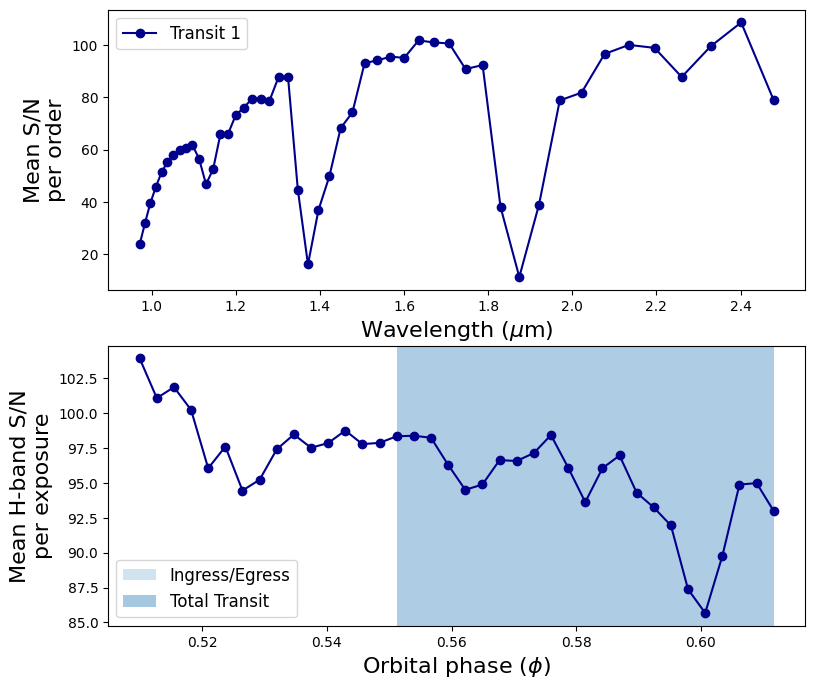

In [29]:
# Plot airmass and mean SNR per order/exposure

for seq_obj in seq_obj_list:
    pf.plot_airmass([seq_obj])

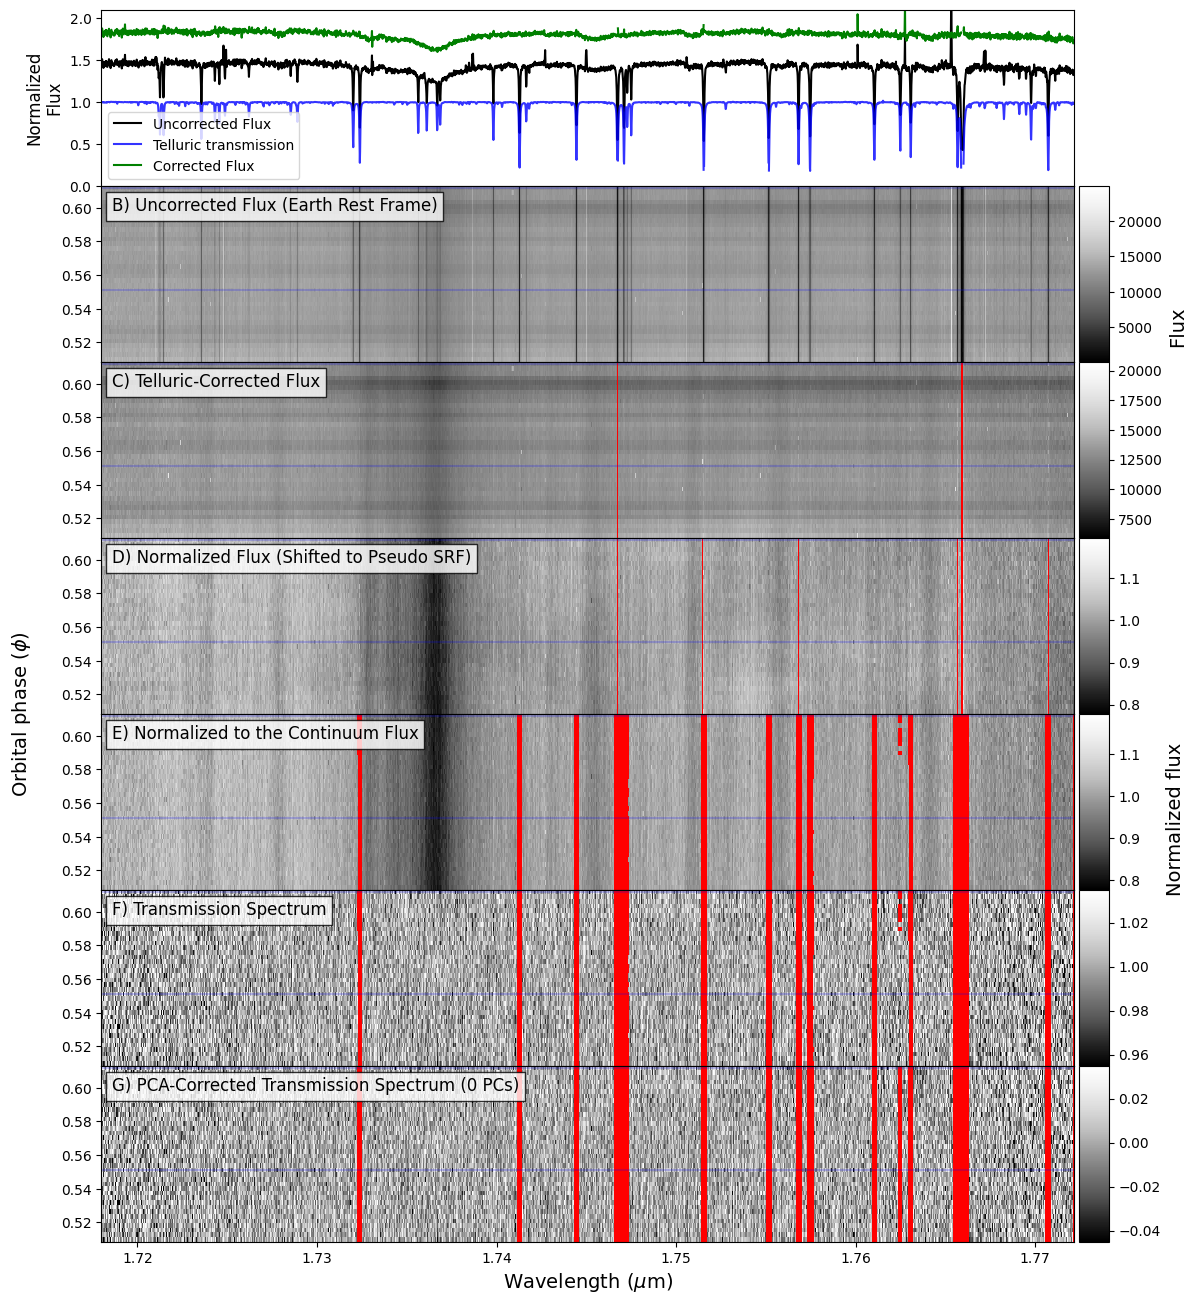

In [30]:
# Order to plot
order_plot = 36
#--------------#

# Plot the reductions steps

for seq_obj in seq_obj_list:
    plot_steps = pf.plot_steps(seq_obj, order_plot - 1)

plt.show()

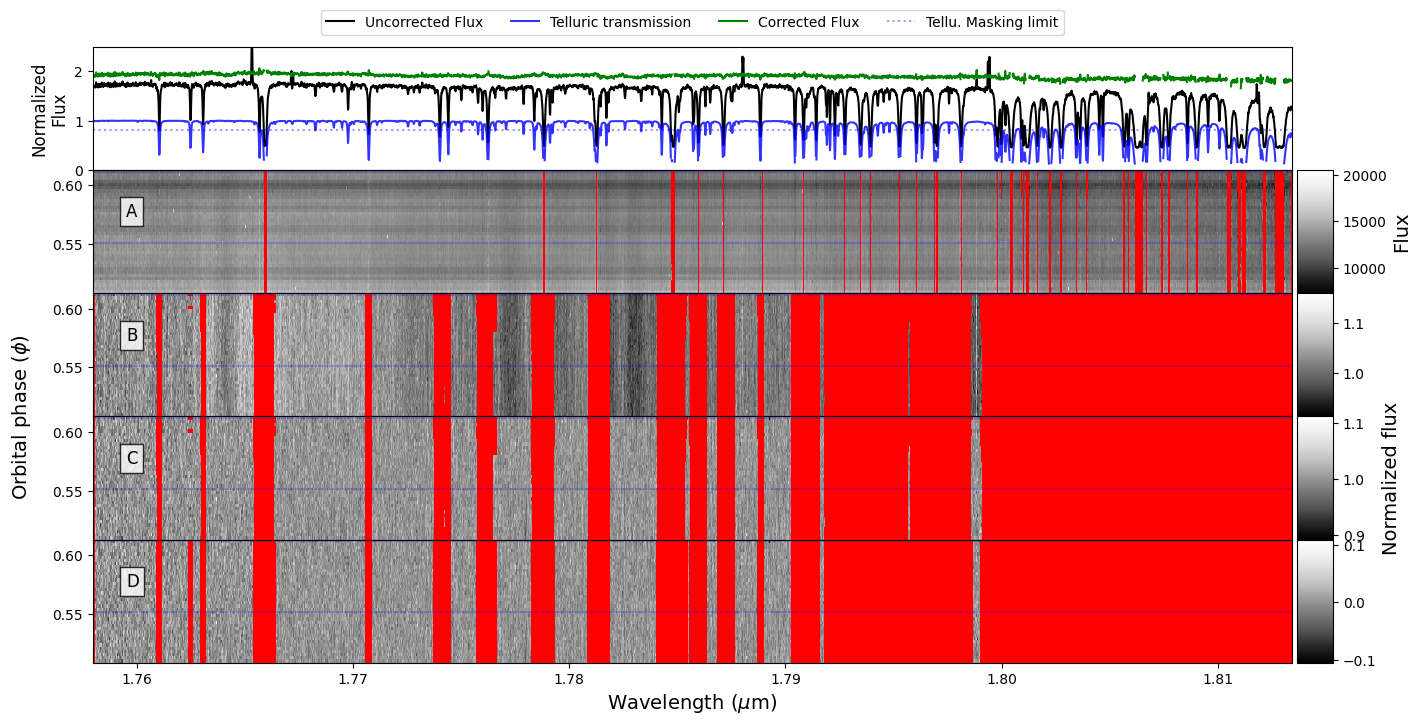

In [31]:
# Plot fewer steps

for seq_obj in seq_obj_list:
    plot_few_steps = pf.plot_five_steps(seq_obj, order_plot)

The fraction of masked data points is 0.4364266743879548


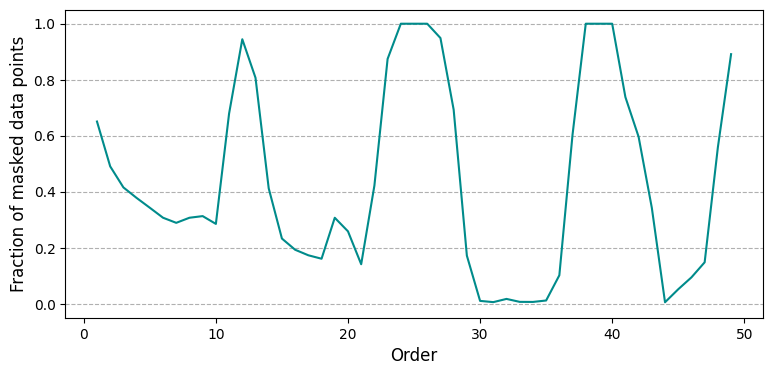

In [32]:
# Plot ratio of masked data points at each order

# Calculate overall ratio of masked data points
masked_ratio_total = [seq_obj.final.mask.sum() / seq_obj.final.size for seq_obj in seq_obj_list]
print("The fraction of masked data points is", masked_ratio_total[0])

# Plot ratio of masked data points per order, for each nPC
masked_ratio = np.array([seq_obj.final.mask.sum(axis=0).sum(axis=-1) / seq_obj.final.shape[0] / seq_obj.final.shape[-1]
                         for seq_obj in seq_obj_list])

n_pc_list = np.array([seq_obj.params[5] for seq_obj in seq_obj_list])  # list of nPC for each observation

fig, axs = plt.subplots(len(n_pc_list), sharex=True, squeeze=False, figsize=(9,4))

for n in range(len(n_pc_list)):
    order_list = np.arange(1, len(masked_ratio[n]) + 1)
    axs[n,0].plot(order_list, masked_ratio[n], color="darkcyan")
    axs[n,0].grid(axis='y', linestyle='--')
    axs[n,0].set_ylim(-0.05,1.05)
#    axs[n,0].set_title("{} PC removed".format(n_pc_list[n]))

axs[len(n_pc_list) // 2, 0].set_ylabel("Fraction of masked data points", fontsize=12)
plt.xlabel("Order", fontsize=12)
plt.show()

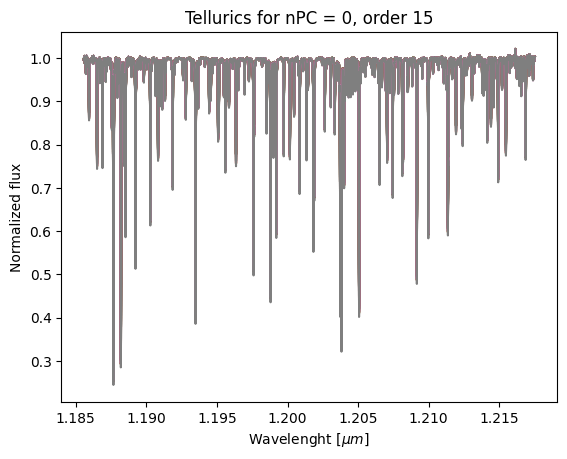

In [17]:
#-----------------------------------------------#
# Plot tellurics for a specific nPC and order
tellu_plot_nPC = 0
tellu_plot_order = 15
#-----------------------------------------------#

nPC_idx = np.where(n_pc_list == tellu_plot_nPC)[0][0]
plt.plot(seq_obj_list[nPC_idx].wave[:, tellu_plot_order, :].T, seq_obj_list[nPC_idx].tellu[:, tellu_plot_order, :].T)

plt.title("Tellurics for nPC = {}, order {}".format(tellu_plot_nPC, tellu_plot_order))
plt.xlabel("Wavelenght [$\mu{}m$]")
plt.ylabel("Normalized flux")
plt.show()

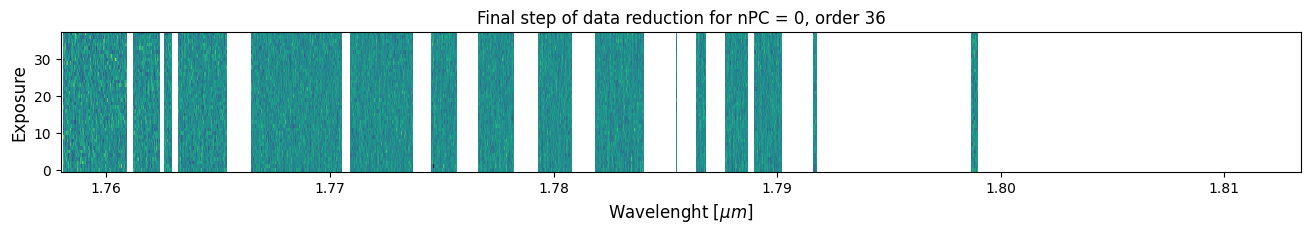

In [18]:
#---------------------------------------------------------------#
# Plot final step of data reduction for a specific nPC and order
final_plot_nPC = 0
final_plot_order = 36
#---------------------------------------------------------------#

nPC_idx = np.where(n_pc_list == final_plot_nPC)[0][0]
pf.plot_order(seq_obj_list[nPC_idx], final_plot_order, xlabel="Wavelenght [$\mu{}m$]", ylabel="Exposure",
              title="Final step of data reduction for nPC = {}, order {}".format(final_plot_nPC, final_plot_order))

# Plots from Correlations. Fix them.

In [15]:
## they were originally juste before Combine visits, so they might use variables that were defined in correlations

## this plots the model order by order. all the wavelengths that are masked in the reduction are also masked in this plot.

In [16]:

fct_model = interp1d(wave_mod, model_spec, kind='cubic')

NameError: name 'interp1d' is not defined

In [ ]:
# Orders to plot
order_plot = [15, 16, 17, 33, 39, 46, 47]

#---------------------------------------------------------------


fct_model = interp1d(wave_mod, model_spec, kind='cubic')

for i_ord in order_plot:

    wv_ord = all_obs[(n_pc, mask_wings)].wv[i_ord]
    mask_ord = all_obs[(n_pc, mask_wings)].final.mask[0, i_ord]
    
    coeff = np.polyfit(wv_ord, fct_model(wv_ord), 1)
    model_ord = np.ma.array(fct_model(wv_ord), mask=mask_ord)
    
    plt.figure()
#     plt.plot(wave_mod[cond], model_spec[cond])
    poly_fct = np.poly1d(coeff)
    plt.plot(wv_ord, model_ord / poly_fct(wv_ord))
    plt.title("Order #" + str(i_ord))
    
#     plt.gca().twinx().plot(wv_ord, mask_ord, 'r')